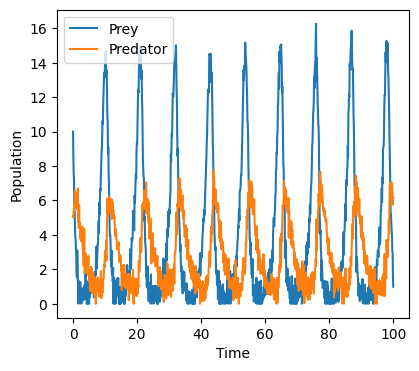

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

def lotka_volterra(t, state, a, b, c, d):
    x, y = state
    dxdt = a*x - b*x*y
    dydt = d*x*y - c*y
    return [dxdt, dydt]

params = (1.1, 0.4, 0.4, 0.1)
initial_pop = [10, 5]
t_span = (0, 100)
t_eval = np.linspace(0, 100, 1000)

sol = solve_ivp(
    lotka_volterra,
    t_span,
    initial_pop,
    args=params,
    t_eval=t_eval
)

noise_scale = .5

sol.y[0] += np.random.normal(0, noise_scale, size=len(sol.t))
sol.y[1] += np.random.normal(0, noise_scale, size=len(sol.t))

sol.y[0] = np.clip(sol.y[0], 0, None)
sol.y[1] = np.clip(sol.y[1], 0, None)


plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.plot(sol.t, sol.y[0], label='Prey')
plt.plot(sol.t, sol.y[1], label='Predator')
plt.xlabel('Time')
plt.ylabel('Population')
plt.legend()

plt.show()

Discovered Equations:
(x)' =  1.003 x + -0.362 x y
(y)' = -0.392 y +  0.096 x y


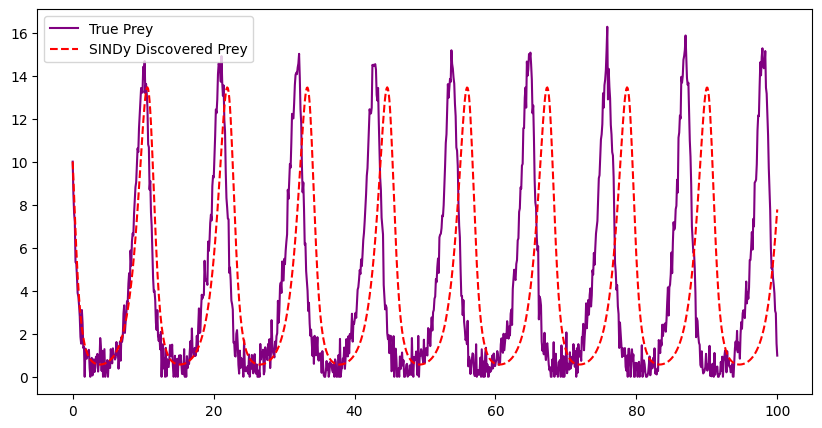

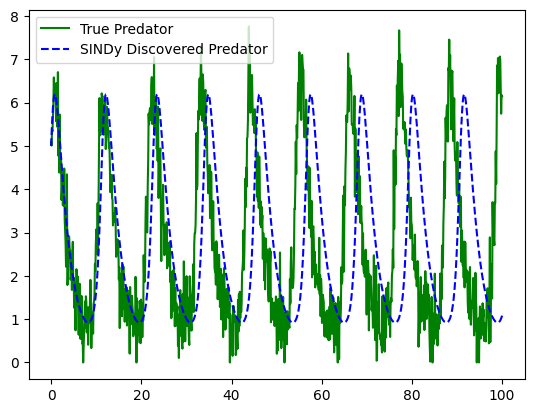

In [9]:
import pysindy as ps


x = sol.y[0]
y = sol.y[1]
t = sol.t

differentiation_method = ps.FiniteDifference(order=2)
feature_library = ps.PolynomialLibrary(degree=2)

optimizer = ps.STLSQ(threshold=0.05)
model = ps.SINDy(
    differentiation_method=differentiation_method,
    feature_library=feature_library,
    optimizer=optimizer,
)

X = np.stack((x, y), axis=-1)
model.fit(X, t=t, feature_names=["x", "y"])

print("Discovered Equations:")
model.print()

x_sim = model.simulate(initial_pop, t_eval)

plt.figure(figsize=(10, 5))
plt.plot(t_eval, sol.y[0],linestyle="solid", color="purple", marker="None", label='True Prey')
plt.plot(t_eval, x_sim[:, 0], 'r--', label='SINDy Discovered Prey')
plt.legend()
plt.show()
plt.figure()
plt.plot(t_eval, sol.y[1], 'g-', label='True Predator')
plt.plot(t_eval, x_sim[:, 1], 'b--', label='SINDy Discovered Predator')
plt.legend()
plt.show()